# NonlinearEquality Example


```
GTSAM Copyright 2010-2018, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved
Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

NonlinearEquality example using a simple Pose2 chain
Author: Frank Dellaert (Python)
```

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/NonlinearEqualityExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


This notebook illustrates the use of the `NonlinearEquality` factor to clamp certain variables to a known value. This is the preferred way to work with known values, as the alternative of adding strong priors can make the system ill-conditioned.

Below we build a 7-pose `Pose2` SLAM chain with only between factors. We compare marginal covariances for three different prior strengths, then replace the prior with a hard `NonlinearEqualityPose2`, and finally remove the first pose while converting the first between factor into an equivalent prior on `X(2)` to show the marginals match.


## 1. Setup and Imports

Install GTSAM if running in Colab, then import the needed modules.


In [1]:
# Install GTSAM from pip if running in Google Colab
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gtsam
import gtsam.utils.plot as gtsam_plot
from gtsam.symbol_shorthand import X

np.set_printoptions(precision=3, suppress=True)


## 2. Problem Setup

We use a 7-pose chain with identical odometry measurements and a simple initial guess. The only factors are a prior (or a `NonlinearEquality`) on the first pose and between factors connecting consecutive poses.


In [3]:
NUM_POSES = 7
PRIOR_POSE = gtsam.Pose2(0.0, 0.0, 0.0)
ODOM = gtsam.Pose2(2.0, 0.0, 0.1)
BETWEEN_NOISE = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))

def build_initial(drop_first=False, fixed_first=False):
    initial = gtsam.Values()
    if fixed_first:
        current = PRIOR_POSE
    else:
        current = PRIOR_POSE.compose(gtsam.Pose2(0.3, -0.2, 0.1))
    if not drop_first:
        initial.insert(X(1), current)
    for i in range(2, NUM_POSES + 1):
        current = current.compose(ODOM)
        initial.insert(X(i), current)
    return initial

def optimize_graph(graph, initial, use_qr=False):
    params = gtsam.LevenbergMarquardtParams()
    if use_qr:
        params.setLinearSolverType("MULTIFRONTAL_QR")
    optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, params)
    return optimizer.optimize()

def plot_marginals(ax, result, marginals, pose_indices, title):
    for i in pose_indices:
        gtsam_plot.plot_pose2_on_axes(
            ax,
            result.atPose2(X(i)),
            axis_length=0.3,
            covariance=marginals.marginalCovariance(X(i)),
        )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")


## 3. Comparing Prior Strengths

We solve the same chain three times with different prior standard deviations. Smaller sigmas mean a stronger prior.


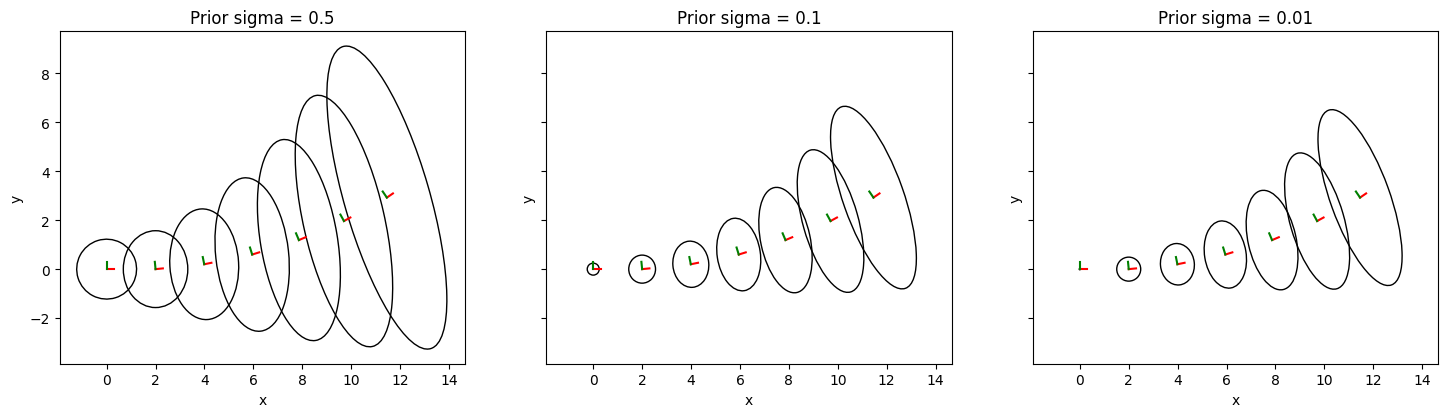

In [4]:
deg20 = np.deg2rad(20)
prior_sigmas = [0.5, 0.1, 0.01]
prior_results = []

for sigma in prior_sigmas:
    prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([sigma, sigma, sigma*deg20]))
    graph = gtsam.NonlinearFactorGraph()
    graph.add(gtsam.PriorFactorPose2(X(1), PRIOR_POSE, prior_noise))
    for i in range(1, NUM_POSES):
        graph.add(gtsam.BetweenFactorPose2(X(i), X(i + 1), ODOM, BETWEEN_NOISE))
    initial = build_initial()
    result = optimize_graph(graph, initial)
    marginals = gtsam.Marginals(graph, result)
    prior_results.append((sigma, result, marginals))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (sigma, result, marginals) in zip(axes, prior_results):
    plot_marginals(
        ax,
        result,
        marginals,
        pose_indices=range(1, NUM_POSES + 1),
        title=f"Prior sigma = {sigma}",
    )
plt.tight_layout()
plt.show()


## 4. Replacing the Prior with a NonlinearEquality

Here we fix the first pose exactly using `NonlinearEqualityPose2`, which acts as a hard constraint.


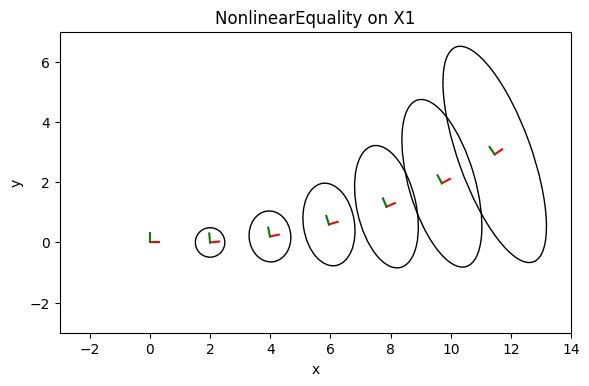

In [5]:
graph_eq = gtsam.NonlinearFactorGraph()
graph_eq.add(gtsam.NonlinearEqualityPose2(X(1), PRIOR_POSE))
for i in range(1, NUM_POSES):
    graph_eq.add(gtsam.BetweenFactorPose2(X(i), X(i + 1), ODOM, BETWEEN_NOISE))
initial_eq = build_initial(fixed_first=True)
result_eq = optimize_graph(graph_eq, initial_eq, use_qr=True)
marginals_eq = gtsam.Marginals(graph_eq, result_eq)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_marginals(
    ax,
    result_eq,
    marginals_eq,
    pose_indices=range(1, NUM_POSES + 1),
    title="NonlinearEquality on X1",
)
ax.set_xlim(-3, 14)
ax.set_ylim(-3, 7)
plt.tight_layout()
plt.show()

## 5. Showing equivalence with a smaller optimization problem.

To convince yourself that this is doing the right thing, let us now undertake a different way of fixing a variable. Below we show that this yields *exactly* the same marginals. In particular, we optimize only over 6 variables now, omitting `X(1)`. With `X(1)` fixed, we can convert the "between" measurement from `X(1)` to `X(2)` into a prior on `X(2)` with the same noise. We drop `X(1)` entirely, add that equivalent prior, then compare marginals.


Max abs covariance entry diff (X2..X7): 3.508e-14


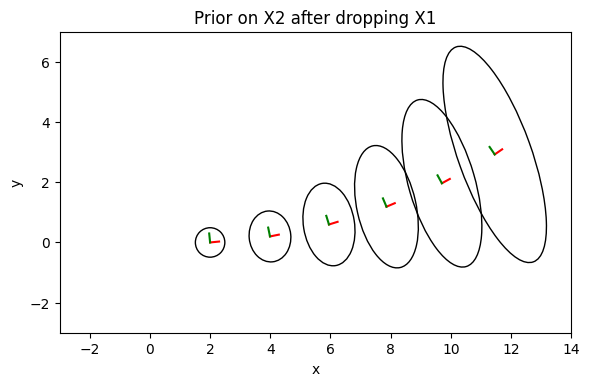

In [7]:
graph_x2 = gtsam.NonlinearFactorGraph()
prior_pose_2 = PRIOR_POSE.compose(ODOM)
graph_x2.add(gtsam.PriorFactorPose2(X(2), prior_pose_2, BETWEEN_NOISE))
for i in range(2, NUM_POSES):
    graph_x2.add(gtsam.BetweenFactorPose2(X(i), X(i + 1), ODOM, BETWEEN_NOISE))
initial_x2 = build_initial(drop_first=True)
result_x2 = optimize_graph(graph_x2, initial_x2, use_qr=True)
marginals_x2 = gtsam.Marginals(graph_x2, result_x2)

max_diff = 0.0
for i in range(2, NUM_POSES + 1):
    cov_eq = marginals_eq.marginalCovariance(X(i))
    cov_x2 = marginals_x2.marginalCovariance(X(i))
    max_diff = max(max_diff, np.max(np.abs(cov_eq - cov_x2)))

print(f"\nMax abs covariance entry diff (X2..X7): {max_diff:.3e}")

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_marginals(
    ax,
    result_x2,
    marginals_x2,
    pose_indices=range(2, NUM_POSES + 1),
    title="Prior on X2 after dropping X1",
)
ax.set_xlim(-3, 14)
ax.set_ylim(-3, 7)
plt.tight_layout()
plt.show()

In [ ]:

# Show covariances for the last pose in Sections 4 and 5.
last_key = X(NUM_POSES)
cov_eq_last = marginals_eq.marginalCovariance(last_key)
cov_x2_last = marginals_x2.marginalCovariance(last_key)
print("\nSection 4 (NonlinearEquality) last pose covariance:\n", cov_eq_last)
print("\nSection 5 (Prior on X2) last pose covariance:\n", cov_x2_last)


Section 4 (NonlinearEquality) last pose covariance:
 [[0.3823628  0.52541169 0.06877334]
 [0.52541169 2.26703813 0.28962002]
 [0.06877334 0.28962002 0.06      ]]

Section 5 (Prior on X2) last pose covariance:
 [[0.3823628  0.52541169 0.06877334]
 [0.52541169 2.26703813 0.28962002]
 [0.06877334 0.28962002 0.06      ]]


## Summary

- Stronger priors tighten the marginal covariances throughout the chain.
- A `NonlinearEqualityPose2` produces a hard anchor on `X(1)`.
- Eliminating `X(1)` and converting the first between factor into a prior on `X(2)` yields matching marginals for `X(2..7)`.
